In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [5]:
df=pd.read_csv("oil_geopolitics_dataset_2010_2026.csv")
df.head()
df

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,2010-02-17,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0.0,0
1,2010-02-18,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0.0,0
2,2010-02-19,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0.0,0
3,2010-02-22,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0.0,0
4,2010-02-23,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4042,2026-03-06,92.690002,90.900002,98.989998,29.490000,130.887665,0.085236,0.122084,85.410004,81.400002,...,65.419998,0.033662,0.029489,0.045250,0.034029,1.790001,none,none,0.0,0
4043,2026-03-09,98.959999,94.769997,99.180000,25.500000,130.887665,0.067645,0.042574,92.690002,81.400002,...,65.209999,0.029502,0.031034,0.039384,0.034316,4.190002,blockade,Closure of Strait of Hormuz shipping lane,10.0,1
4044,2026-03-10,87.800003,83.449997,98.830002,24.930000,130.887665,-0.112773,-0.119447,98.959999,85.410004,...,67.019997,0.068590,0.038639,0.077506,0.042092,4.350006,none,none,0.0,0
4045,2026-03-11,91.980003,87.250000,99.230003,24.230000,130.887665,0.047608,0.045536,87.800003,92.690002,...,71.230003,0.066619,0.039074,0.076723,0.042435,4.730003,none,none,0.0,0


    Tratamiento de datos

In [6]:

Cantidad_nulos= df.isnull().sum()
print(Cantidad_nulos)
cantidad_duplicados=df.duplicated().sum()
print(cantidad_duplicados)

date                    0
brent_price             0
wti_price               0
dxy_index               0
vix                     0
gpr_index               0
brent_return            0
wti_return              0
brent_lag_1             0
brent_lag_3             0
brent_lag_7             0
wti_lag_1               0
wti_lag_3               0
wti_lag_7               0
brent_volatility_7d     0
brent_volatility_30d    0
wti_volatility_7d       0
wti_volatility_30d      0
brent_wti_spread        0
event_type              0
event_description       0
event_severity          0
event_flag              0
dtype: int64
0


In [7]:
# Extracción Año y mes
df["year"]= df["date"].str[0:4]
df["month-year"]= df["date"].str[0:7]

In [8]:
#Agrupaciones de datos por año y por mes
df_año= df.groupby("year")["brent_price"].mean()
df_añoo=df_año .sort_values(ascending=False)
print(df_añoo)
df_mes= df.groupby("month-year")["brent_price"].mean()

year
2012    111.760520
2011    110.950000
2013    108.719723
2014     99.352659
2022     98.966335
2023     82.190438
2010     81.038333
2024     79.821310
2018     71.767171
2026     70.982917
2021     70.953809
2025     68.088419
2019     64.160635
2017     54.726016
2015     53.502262
2016     45.133597
2020     43.086759
Name: brent_price, dtype: float64


Visualización de datos

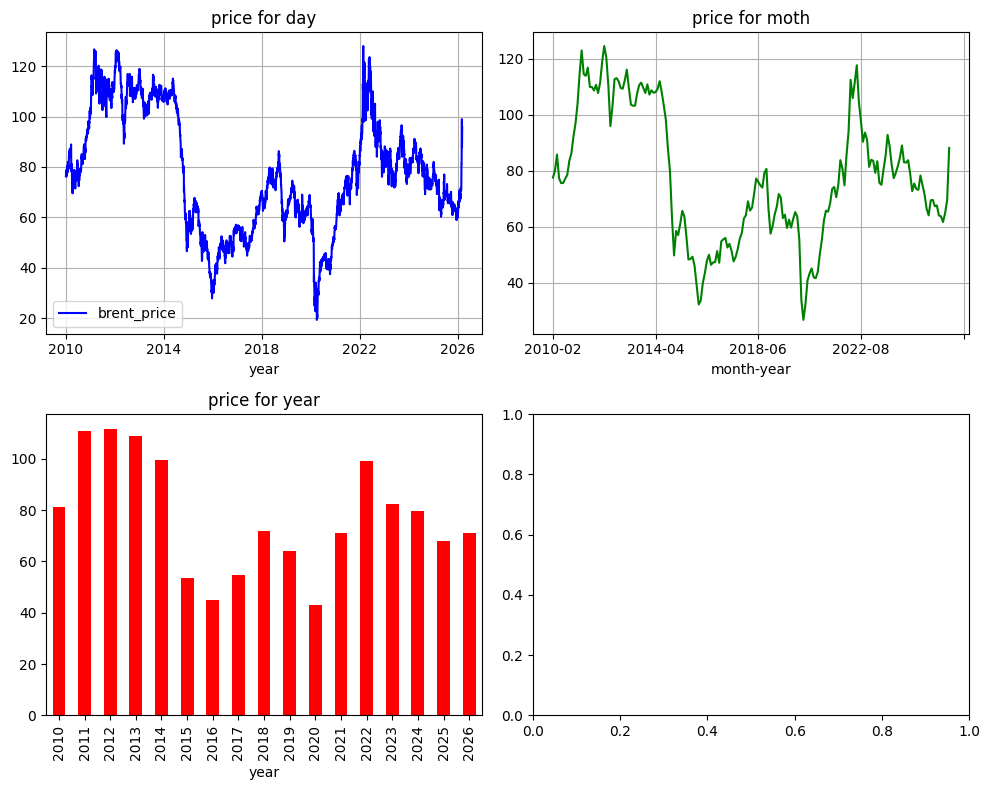

In [9]:
# Graficas por día, año y mes
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

df.plot(x='year', y='brent_price', kind='line', title="price for day", ax=axs[0,0], color="blue", grid=True)

df_mes.plot(x='month-year', y='brent_price', kind='line', ax=axs[0,1],title='price for moth', color="green",grid=True)

df_año.plot(x='year', y='brent_price', kind='bar', ax= axs[1,0], title='price for year', color="red")


plt.tight_layout()
plt.show()

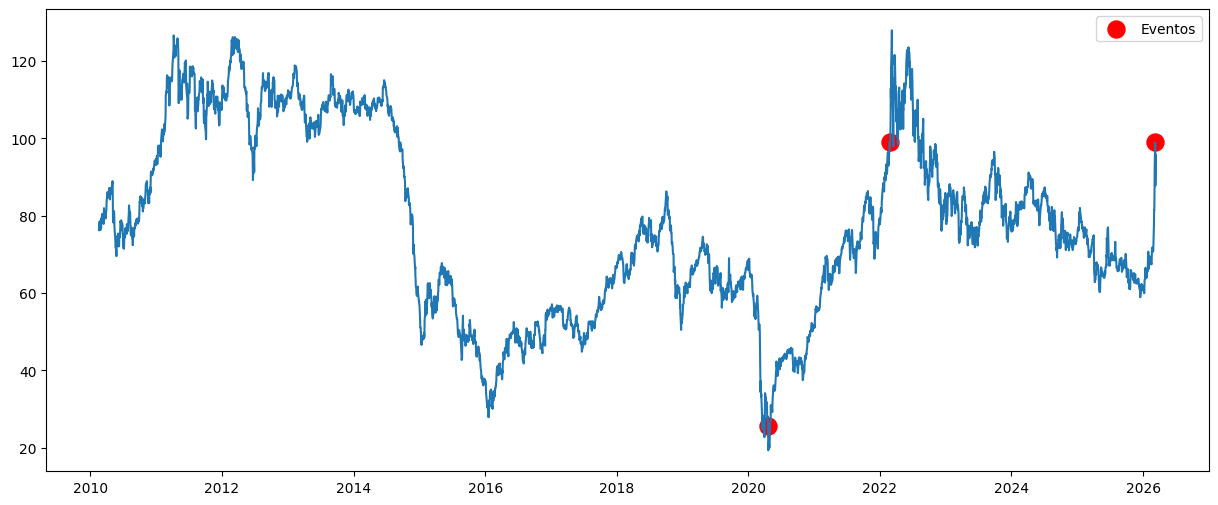

In [ ]:
precio = df['brent_price']

plt.figure(figsize=(15,6))

Eventos_significativos = df[df["event_severity"] > 9]

plt.plot(df["date"], df['brent_price'])


plt.scatter(Eventos_significativos['date'],
            Eventos_significativos['brent_price'],
            s=150,
            label='Eventos',
            color= "red")


plt.legend()
plt.show()

PRONOSTICO

MODELO (AR)

In [11]:
model_ar=AutoReg(df['brent_price'],lags=900)
model_ar_fit=model_ar.fit()
pronostico=model_ar_fit.predict(start=len(df), end=len(df)+900, dynamic=False)


In [12]:

df['date'] = pd.to_datetime(df['date'])

ultima_fecha = df['date'].iloc[-1]

fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=901,
    freq='D'
)

pronostico_df = pd.DataFrame({
    'date': fechas_futuras,
    'brent_price': pronostico
})

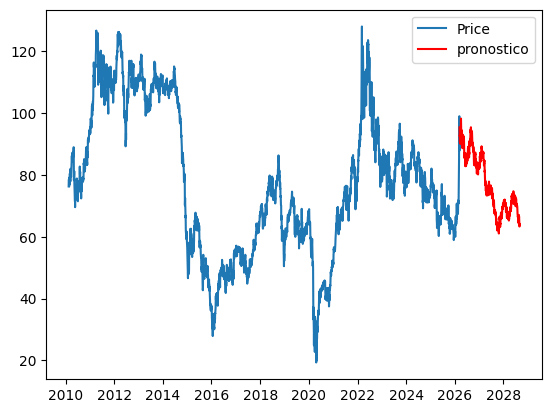

In [13]:
plt.plot(df ["date"],df["brent_price"],label="Price")
plt.plot(pronostico_df["date"],pronostico_df ["brent_price"],label= "pronostico", color="red")
plt.legend()
plt.show()

In [14]:
resultado = adfuller(df['brent_price'])

print('p-value:', resultado[1])


p-value: 0.33806779105715545


MODELO (ARIMA)

In [15]:
model_ar=ARIMA(df['brent_price'],order=(3,1,3) )
model_ar_fit=model_ar.fit()
pronostico=model_ar_fit.predict(start=len(df), end=len(df)+600, dynamic=False)  

In [16]:

df['date'] = pd.to_datetime(df['date'])

ultima_fecha = df['date'].iloc[-1]

fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=601,
    freq='D'
)

pronostico_df = pd.DataFrame({
    'date': fechas_futuras,
    'brent_price': pronostico
})

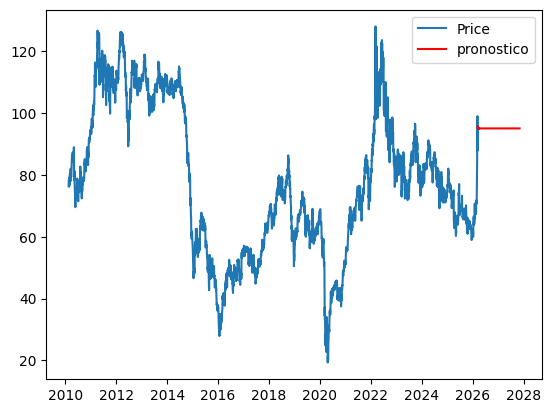

In [17]:
plt.plot(df ["date"],df["brent_price"],label="Price")
plt.plot(pronostico_df["date"],pronostico_df ["brent_price"],label= "pronostico", color="red")
plt.legend()
plt.show()